In [1]:
# Cell 1: Install and import required libraries
# Install seaborn if not already installed
import sys
!{sys.executable} -m pip install seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    confusion_matrix, 
    classification_report,
    roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Cell 2: Load dataset from Azure ML Data Assets
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

# Connect to Azure ML workspace
ml_client = MLClient.from_config(credential=DefaultAzureCredential())

# Get the registered data asset
data_asset = ml_client.data.get(name="diabetes-dataset", label="latest")

# Load the data
df = pd.read_csv(data_asset.path)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())
print("\nTarget Distribution:")
print(df['Outcome'].value_counts())

Found the config file in: /config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instru

Dataset Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 

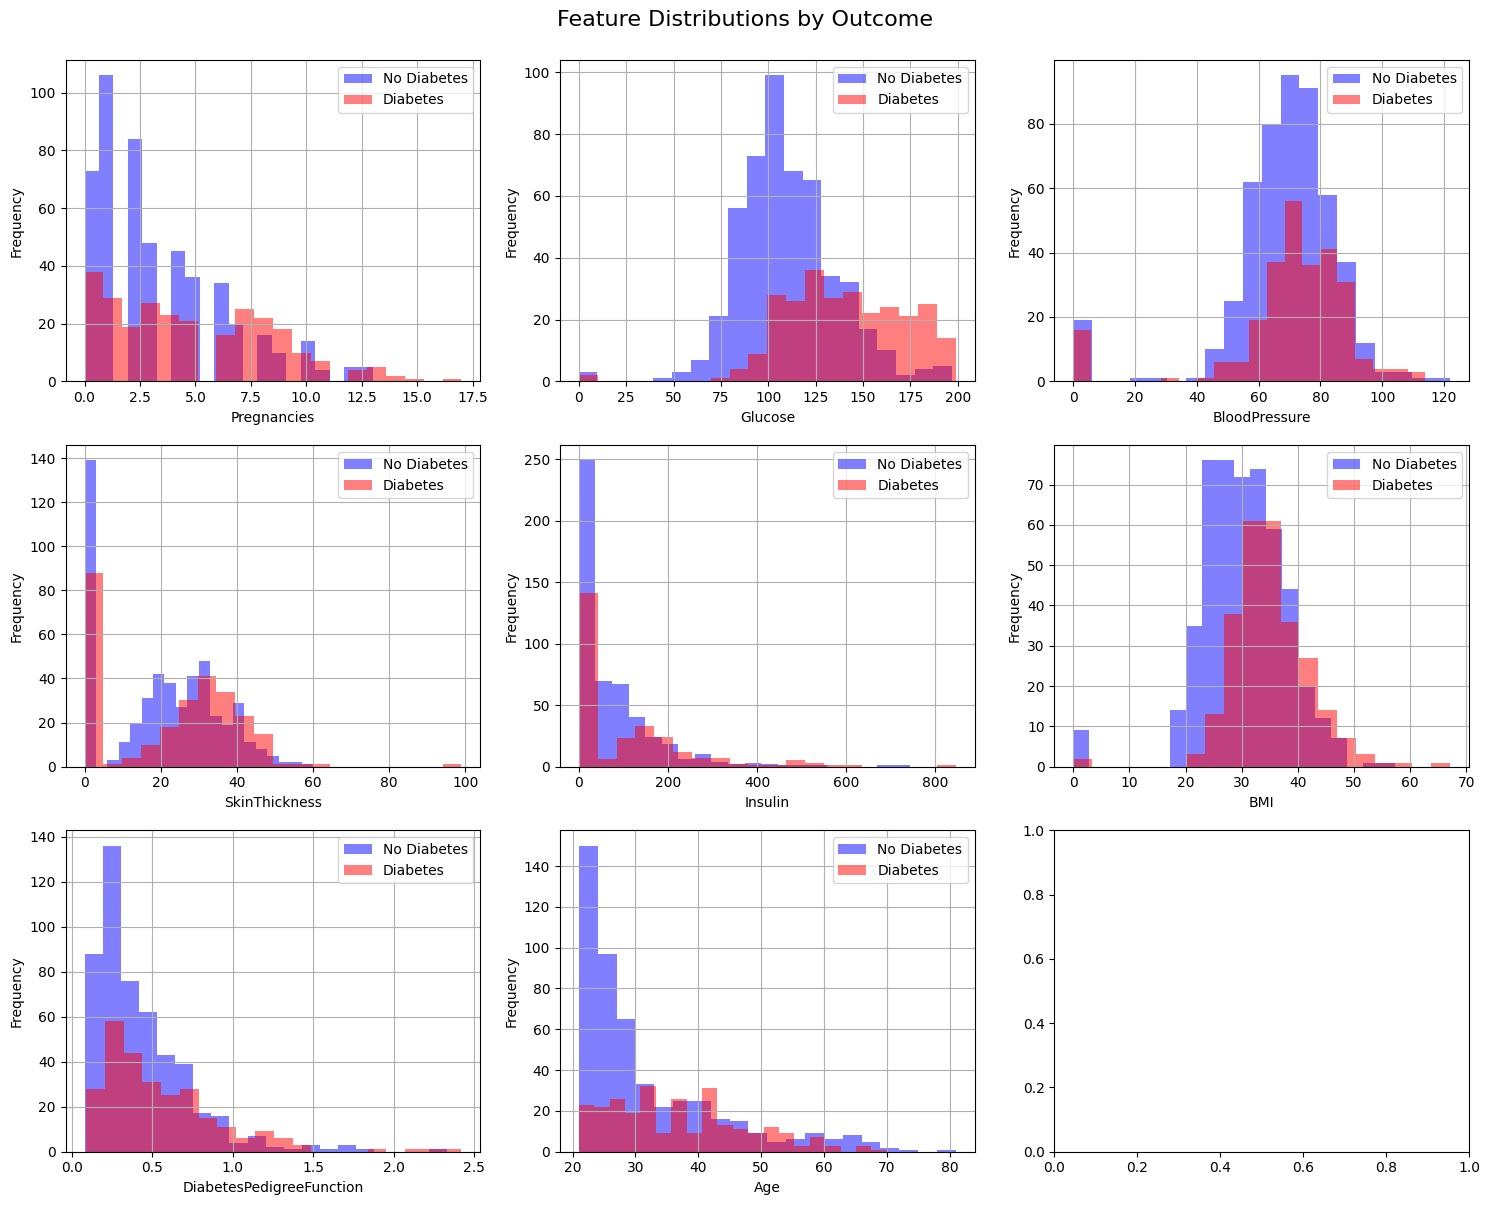

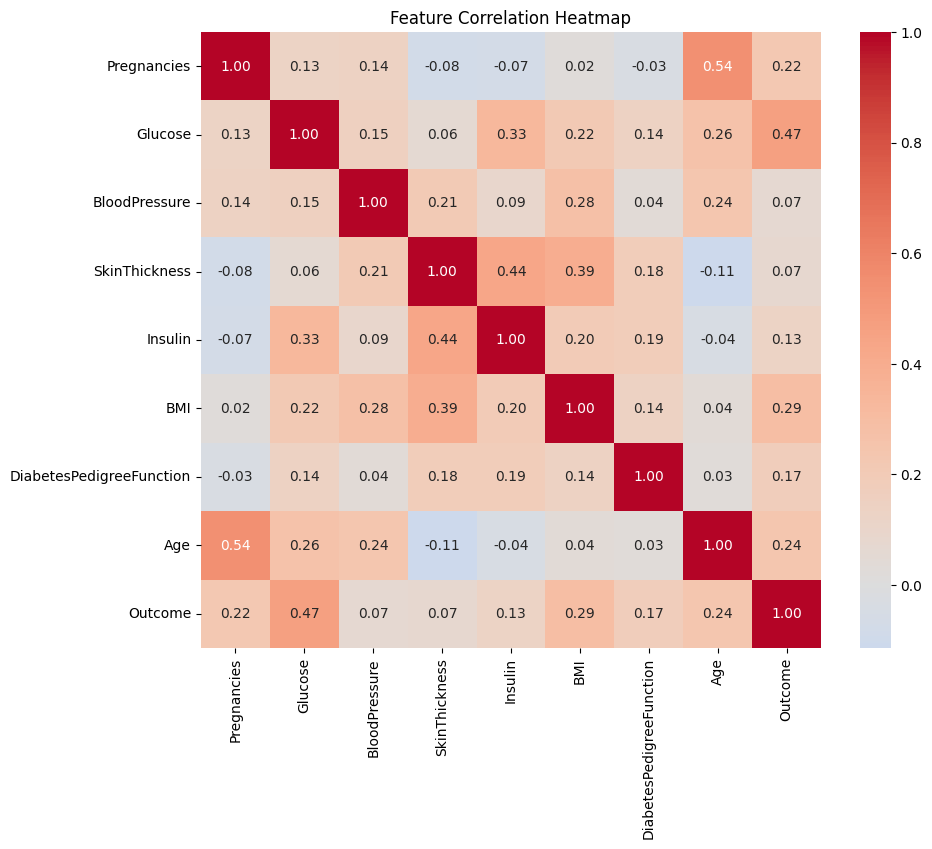

✅ EDA visualizations complete


In [3]:
# Cell 3: Exploratory Data Analysis
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Feature Distributions by Outcome', fontsize=16, y=1.00)

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    df[df['Outcome']==0][feature].hist(bins=20, alpha=0.5, label='No Diabetes', ax=ax, color='blue')
    df[df['Outcome']==1][feature].hist(bins=20, alpha=0.5, label='Diabetes', ax=ax, color='red')
    
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

print("✅ EDA visualizations complete")

In [4]:
# Cell 4: Data Preprocessing
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data preprocessing complete")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:")
print(pd.Series(y_train).value_counts(normalize=True))
print(f"\nTest set target distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

✅ Data preprocessing complete
Training set size: 614 samples
Test set size: 154 samples

Training set target distribution:
0    0.651466
1    0.348534
Name: Outcome, dtype: float64

Test set target distribution:
0    0.649351
1    0.350649
Name: Outcome, dtype: float64


In [5]:
# Cell 5: Train multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print('='*60)
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results[model_name] = {
        'Model': model,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc,
        'Predictions': y_pred,
        'Probabilities': y_pred_proba
    }
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")

print("\n✅ Model training complete")


Training Logistic Regression...
Accuracy:  0.7143
Precision: 0.6087
Recall:    0.5185
F1-Score:  0.5600
AUC:       0.8230

Training Random Forest...
Accuracy:  0.7597
Precision: 0.6809
Recall:    0.5926
F1-Score:  0.6337
AUC:       0.8147

Training Gradient Boosting...
Accuracy:  0.7532
Precision: 0.6667
Recall:    0.5926
F1-Score:  0.6275
AUC:       0.8389

✅ Model training complete


Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.714286   0.608696 0.518519  0.560000 0.822963
      Random Forest  0.759740   0.680851 0.592593  0.633663 0.814722
  Gradient Boosting  0.753247   0.666667 0.592593  0.627451 0.838889

🏆 Best Model: Gradient Boosting (AUC: 0.8389)


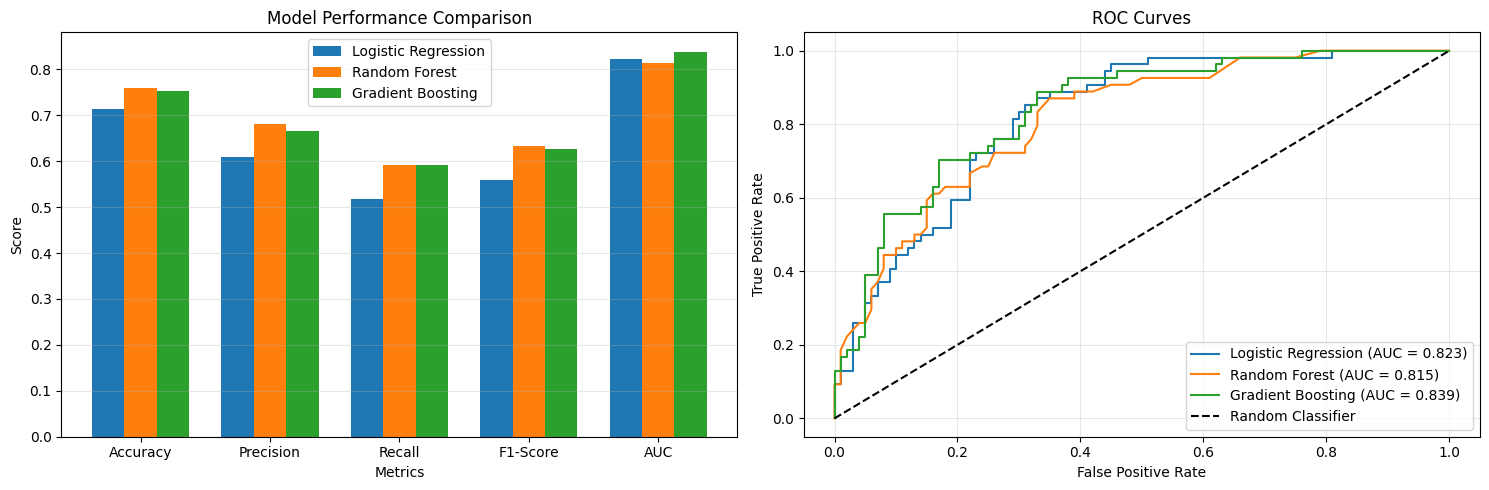

In [6]:
# Cell 6: Compare model performance
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
    'Precision': [results[m]['Precision'] for m in results.keys()],
    'Recall': [results[m]['Recall'] for m in results.keys()],
    'F1-Score': [results[m]['F1-Score'] for m in results.keys()],
    'AUC': [results[m]['AUC'] for m in results.keys()]
})

print("Model Performance Comparison:")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Identify best model by AUC
best_model_name = comparison_df.loc[comparison_df['AUC'].idxmax(), 'Model']
best_auc = comparison_df.loc[comparison_df['AUC'].idxmax(), 'AUC']
print(f"\n🏆 Best Model: {best_model_name} (AUC: {best_auc:.4f})")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics))
width = 0.25

for idx, model_name in enumerate(results.keys()):
    values = [results[model_name][metric] for metric in metrics]
    axes[0].bar(x + (idx * width), values, width, label=model_name)

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ROC Curves
for model_name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[model_name]['Probabilities'])
    auc_score = results[model_name]['AUC']
    axes[1].plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

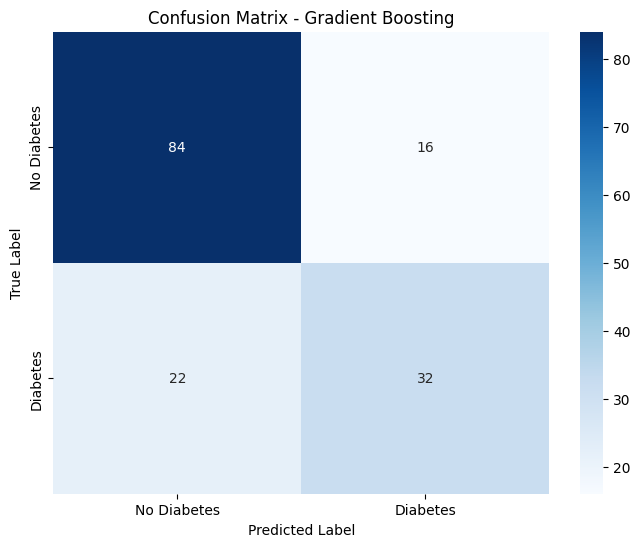


Classification Report - Gradient Boosting:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.84      0.82       100
    Diabetes       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


Feature Importance:
                 Feature  Importance
                 Glucose    0.420566
                     BMI    0.193660
                     Age    0.122699
DiabetesPedigreeFunction    0.122236
                 Insulin    0.050948
             Pregnancies    0.047106
           BloodPressure    0.028581
           SkinThickness    0.014204


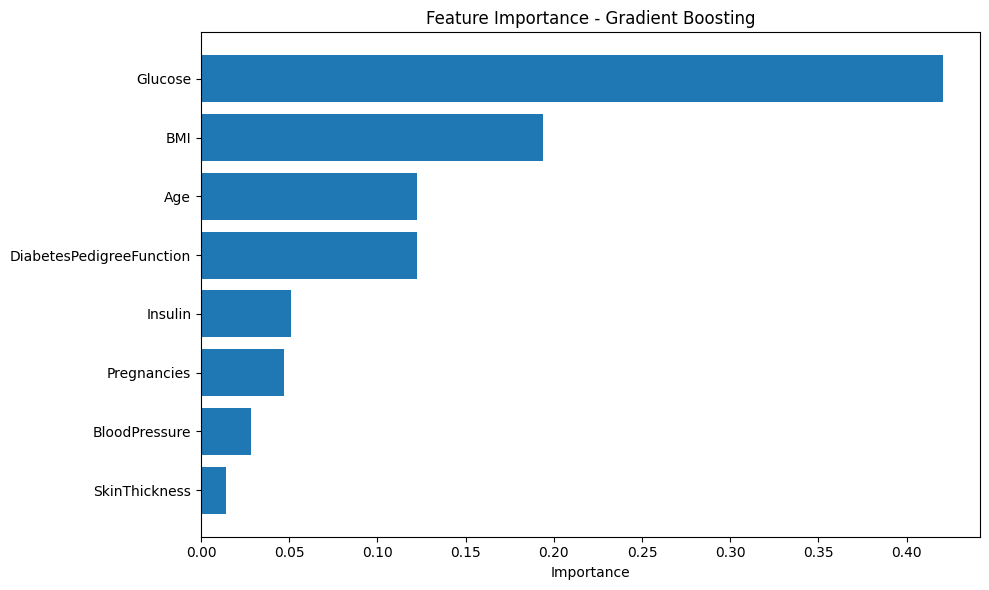


✅ Detailed analysis complete


In [7]:
# Cell 7: Detailed analysis of best model
best_model = results[best_model_name]['Model']
best_predictions = results[best_model_name]['Predictions']

# Confusion Matrix
cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print(f"\nClassification Report - {best_model_name}:")
print("="*60)
print(classification_report(y_test, best_predictions, 
                          target_names=['No Diabetes', 'Diabetes']))

# Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance:")
    print("="*60)
    print(feature_importance.to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print("\n✅ Detailed analysis complete")

In [8]:
# Cell 8: Save the best model
import joblib
from azure.ai.ml.entities import Model
from azure.ai.ml.constants import AssetTypes

# Save model locally first
model_filename = f"diabetes_model_{best_model_name.replace(' ', '_').lower()}.pkl"
joblib.dump(best_model, model_filename)
print(f"✅ Model saved locally as: {model_filename}")

# Register model in Azure ML
try:
    model = Model(
        path=model_filename,
        type=AssetTypes.CUSTOM_MODEL,
        name="diabetes-manual-model",
        description=f"Best manual model: {best_model_name}",
        properties={
            "algorithm": best_model_name,
            "auc": f"{best_auc:.4f}",
            "framework": "scikit-learn"
        }
    )
    
    registered_model = ml_client.models.create_or_update(model)
    print(f"✅ Model registered in Azure ML")
    print(f"Model name: {registered_model.name}")
    print(f"Model version: {registered_model.version}")
    
except Exception as e:
    print(f"⚠️ Model registration failed: {str(e)}")
    print("This is expected if you don't have permissions to register models")

print("\n" + "="*60)
print("NOTEBOOK TRAINING COMPLETE")
print("="*60)
print(f"Best Model: {best_model_name}")
print(f"AUC Score: {best_auc:.4f}")
print("="*60)

✅ Model saved locally as: diabetes_model_gradient_boosting.pkl
✅ Model registered in Azure ML
Model name: diabetes-manual-model
Model version: 2

NOTEBOOK TRAINING COMPLETE
Best Model: Gradient Boosting
AUC Score: 0.8389


In [10]:
# Cell 9: Final Comparison - AutoML vs Manual Training
print("="*80)
print("FINAL COMPARISON: AutoML vs Manual Training")
print("="*80)

print("\n📊 MANUAL TRAINING RESULTS (This Notebook):")
print("-"*80)
print(comparison_df.to_string(index=False))
print(f"\nBest Manual Model: {best_model_name}")
print(f"Best Manual AUC: {best_auc:.4f}")

print("\n\n🤖 AUTOML RESULTS:")
print("-"*80)
print("Go to: Automated ML > automl-diabetes-classification > Models + child jobs tab")
print("Review the best model's performance metrics")

print("\n\n💡 KEY INSIGHTS:")
print("-"*80)
print("1. AutoML Advantages:")
print("   ✅ Automatically tests multiple algorithms")
print("   ✅ Performs hyperparameter tuning")
print("   ✅ Provides model explanations")
print("   ✅ Faster time to first model")
print("   ✅ No coding required")

print("\n2. Manual Training Advantages:")
print("   ✅ Full control over data preprocessing")
print("   ✅ Custom feature engineering")
print("   ✅ Detailed exploratory data analysis")
print("   ✅ Better understanding of data and models")
print("   ✅ Custom evaluation metrics and visualizations")

print("\n3. Recommendation:")
print("   • Use AutoML for rapid prototyping and baseline models")
print("   • Use Manual approach for production models requiring customization")
print("   • Combine both: Start with AutoML, then refine manually")

print("\n" + "="*80)

FINAL COMPARISON: AutoML vs Manual Training

📊 MANUAL TRAINING RESULTS (This Notebook):
--------------------------------------------------------------------------------
              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.714286   0.608696 0.518519  0.560000 0.822963
      Random Forest  0.759740   0.680851 0.592593  0.633663 0.814722
  Gradient Boosting  0.753247   0.666667 0.592593  0.627451 0.838889

Best Manual Model: Gradient Boosting
Best Manual AUC: 0.8389


🤖 AUTOML RESULTS:
--------------------------------------------------------------------------------
Go to: Automated ML > automl-diabetes-classification > Models + child jobs tab
Review the best model's performance metrics


💡 KEY INSIGHTS:
--------------------------------------------------------------------------------
1. AutoML Advantages:
   ✅ Automatically tests multiple algorithms
   ✅ Performs hyperparameter tuning
   ✅ Provides model explanations
   ✅ Faster time to first model
  